In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from data_statistic import calcular_medidas_descritivas, analisar_dispersao_dados, analisar_assimetria_dados, analisar_curtose_dados, gerar_painel_boxplot

## Painel Estatístico em Big Data

In [7]:
df_faturamento = pd.read_csv('../../Dados_tratados/olist_pedidos_faturamento_real.csv')
array_valores = df_faturamento['valor_total_pedido']

### Métricas: Média, Mediana, Quartis, IQR, Limites

Medidas descritivas calculadas com sucesso! 


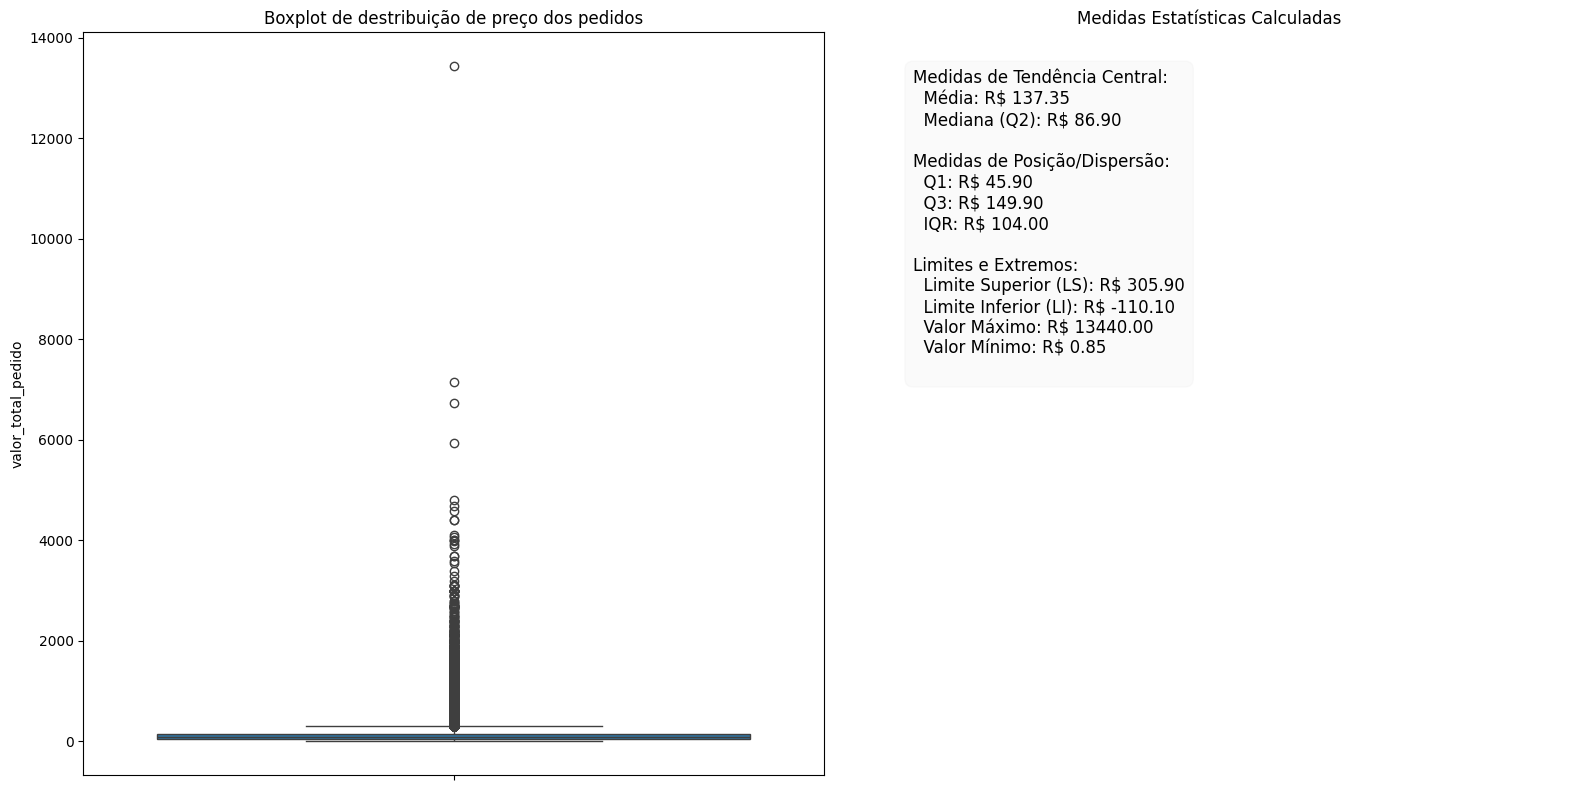

In [12]:
# Realizar analise descritiva da coluna price (preços dos pedidos).
medidas_descritivas = calcular_medidas_descritivas(array_valores)
gerar_painel_boxplot(array_valores, medidas_descritivas, 'Boxplot de destribuição de preço dos pedidos')


### Forma e Posição: Assimetria, Curtose e Dispersão

In [13]:
# Calcular dispersão
dispersao = analisar_dispersao_dados(array_valores,medidas_descritivas)

# Calcular assimetria
assimetria = analisar_assimetria_dados(medidas_descritivas)

# Calcular curtose
curtose = analisar_curtose_dados(medidas_descritivas)


Conclusão da Dispersão: Alta dispersão dos dados em relação à média.

Conclusão da Assimetria: Positiva. A cauda se estende para a direita (valores maiores). Média > Mediana.

Conclusão da Curtose: Leptocúrtica. Dados extremamente concentrados no centro e caudas pesadas. Outiliers muito comuns.


### Outliers

In [26]:
print(f"\nLimites para Outliers: Inferior ({medidas_descritivas['limite_inferior']}) | Superior ({medidas_descritivas['limite_superior']})")

outliers = df_faturamento[
    (df_faturamento['valor_total_pedido'] < medidas_descritivas['limite_inferior']) | 
    (df_faturamento['valor_total_pedido'] > medidas_descritivas['limite_superior'])
]

print(f"Quantidade de pedidos validos total: {len(df_faturamento['valor_total_pedido'])}")
print(f"Quantidade de pedidos considerados Outliers: {len(outliers['valor_total_pedido'])}")

print("Exemplos de valores discrepantes:")
display(outliers.head())


Limites para Outliers: Inferior (-110.1) | Superior (305.9)
Quantidade de pedidos validos total: 85652
Quantidade de pedidos considerados Outliers: 6824
Exemplos de valores discrepantes:


,order_id,valor_total_pedido
7,000576fe39319847cbb9d288c5617fa6,810.0
15,0009c9a17f916a706d71784483a5d643,639.0
29,00137e170939bba5a3134e2386413108,397.0
36,0017afd5076e074a48f1f1a4c7bac9c5,809.1
55,0025c5d1a8ca53a240ec2634bb4492ea,390.0


### Visualização

Grafico histograma salvo em histograma_preco_pedidos.png


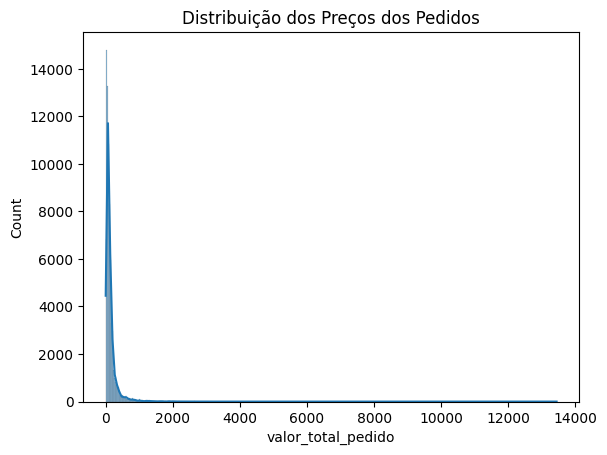

In [30]:
# Gerar Histograma com os preços dos pedidos

sns.histplot(df_faturamento['valor_total_pedido'], kde=True) # kde=True adiciona a curva de densidade, traduzindo seria "Kernel Density Estimate"
plt.title('Distribuição dos Preços dos Pedidos')
plt.savefig('histograma_preco_pedidos.png')
print(f"Grafico histograma salvo em {'histograma_preco_pedidos.png'}")
plt.show()  